In [4]:
import pandas as pd

In [5]:
fake=pd.read_csv("fake.csv")
real=pd.read_csv("true.csv")

In [6]:
fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [7]:
real

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


Check Null values

In [8]:
fake.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [9]:
real.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

Give class labels

In [10]:
fake["label"]=0
real["label"]=1

Merge both dataframes

In [11]:
df_merge=pd.concat([fake,real])

In [12]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Drop columns of no use

In [13]:
df=df_merge.drop(['title','subject', 'date'],axis=1)

In [14]:
df

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0
...,...,...
21412,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
21413,"LONDON (Reuters) - LexisNexis, a provider of l...",1
21414,MINSK (Reuters) - In the shadow of disused Sov...,1
21415,MOSCOW (Reuters) - Vatican Secretary of State ...,1


Shuffle the data because otherwise , training will mostly get fake news and testing will get real news

In [15]:
df=df.sample(frac=1)

In [16]:
df

,text,label
19938,MOSCOW (Reuters) - Advance units of the Syrian...,1
14905,SEOUL (Reuters) - The United States top negot...,1
6130,WASHINGTON (Reuters) - President Donald Trump ...,1
18173,LONDON (Reuters) - Low on cash but high on hop...,1
20456,UNITED NATIONS (Reuters) - The U.N. Security C...,1
...,...,...
4296,WASHINGTON (Reuters) - If Democrats thought it...,1
22387,Tune in to the Alternate Current Radio Network...,0
5707,SEOUL (Reuters) - U.S. and South Korean defens...,1
15136,DUBAI (Reuters) - Iran has provided the capabi...,1


Remove the default index after shuffling

In [18]:
df.reset_index(inplace=True)
df.drop(['index'],axis=1,inplace=True)

In [19]:
df

,text,label
0,MOSCOW (Reuters) - Advance units of the Syrian...,1
1,SEOUL (Reuters) - The United States top negot...,1
2,WASHINGTON (Reuters) - President Donald Trump ...,1
3,LONDON (Reuters) - Low on cash but high on hop...,1
4,UNITED NATIONS (Reuters) - The U.N. Security C...,1
...,...,...
44893,WASHINGTON (Reuters) - If Democrats thought it...,1
44894,Tune in to the Alternate Current Radio Network...,0
44895,SEOUL (Reuters) - U.S. and South Korean defens...,1
44896,DUBAI (Reuters) - Iran has provided the capabi...,1


Now I will start with the NLP pipeline

x= input, y= output

In [21]:
x=df['text']
y=df['label']

Feature Extraction is converting text to numbers

In [23]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_df=0.7
)

fit : The vectorizer learns the vocabulary from training data.
transform : It converts text into numerical vectors.

In [59]:
x_train_vec = vectorizer.fit_transform(x_train)

We DO NOT use fit_transform here. Because we must use the same vocabulary learned from training data.

In [60]:
x_test_vec = vectorizer.transform(x_test)

y_train => output ( 0 or 1)
x_train_vec => vectorized version of text, a huge matrix of numbers.
y_pred_nb => predictions made by the model.

# NAIVE BAYES

In [61]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
nb = MultinomialNB()
nb.fit(x_train_vec, y_train)
y_pred_nb = nb.predict(x_test_vec)


Precision answers: When the model predicted this class(0 or 1), how often was it correct?
Recall answers: Of all actual examples of this class, how many did the model find?
Support: Shows how many examples exist in the test set.

In [34]:
print("NB Accuracy:", accuracy_score(y_test, y_pred_nb)*100)
print(classification_report(y_test, y_pred_nb))

NB Accuracy: 92.76169265033407
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4734
           1       0.93      0.92      0.92      4246

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



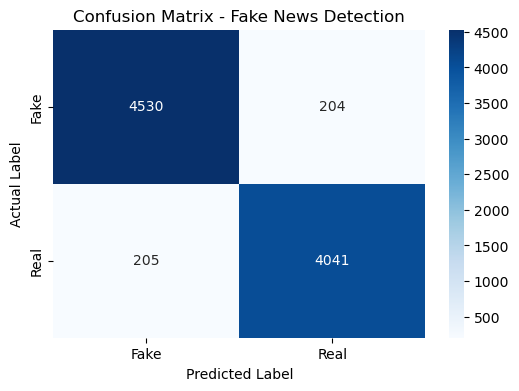

In [62]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Fake News Detection")

plt.show()

# LOGISTIC REGRESSION

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_vec, y_train)

y_pred_lr = lr.predict(x_test_vec)

In [39]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr)*100)
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 98.70824053452117
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4734
           1       0.99      0.99      0.99      4246

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



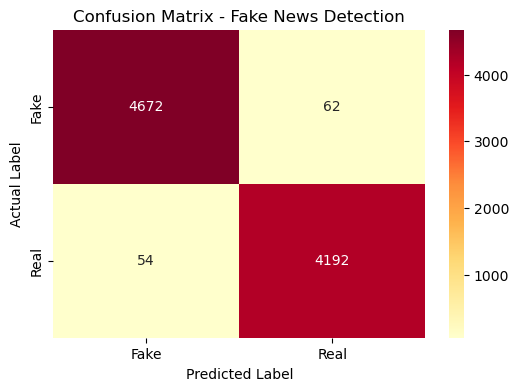

In [46]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=["Fake","Real"],
            yticklabels=["Fake","Real"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Fake News Detection")

plt.show()

Project is complete now i will create a basic streamlit interface for easy use

In [47]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [65]:
import pickle

pickle.dump(lr, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))